In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
bitcoin = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=False
)


[*********************100%***********************]  1 of 1 completed


In [3]:
bitcoin.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2020-01-01,7200.174316,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [4]:
ethereum = yf.download(
    "ETH-USD",
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=False
)


[*********************100%***********************]  1 of 1 completed


In [5]:
ethereum.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,,
2020-01-01,130.802002,130.802002,132.835358,129.198288,129.630661,7935230330
2020-01-02,127.410179,127.410179,130.820038,126.954910,130.820038,8032709256
2020-01-03,134.171707,134.171707,134.554016,126.490021,127.411263,10476845358
2020-01-04,135.069366,135.069366,136.052719,133.040558,134.168518,7430904515
2020-01-05,136.276779,136.276779,139.410202,135.045624,135.072098,7526675353


In [6]:
bitcoin = bitcoin[["Open", "Close"]].copy()
ethereum = ethereum[["Open", "Close"]].copy()


In [7]:
bitcoin.columns = ["BTC_Open", "BTC_Close"]
ethereum.columns = ["ETH_Open", "ETH_Close"]


In [8]:
bitcoin.head()

,BTC_Open,BTC_Close
Date,,
2020-01-01,7194.892090,7200.174316
2020-01-02,7202.551270,6985.470215
2020-01-03,6984.428711,7344.884277
2020-01-04,7345.375488,7410.656738
2020-01-05,7410.451660,7411.317383


In [9]:
ethereum.head()

,ETH_Open,ETH_Close
Date,,
2020-01-01,129.630661,130.802002
2020-01-02,130.820038,127.410179
2020-01-03,127.411263,134.171707
2020-01-04,134.168518,135.069366
2020-01-05,135.072098,136.276779


In [10]:
dados = bitcoin.join(ethereum, how="inner")


In [11]:
dados.head()

,BTC_Open,BTC_Close,ETH_Open,ETH_Close
Date,,,,
2020-01-01,7194.892090,7200.174316,129.630661,130.802002
2020-01-02,7202.551270,6985.470215,130.820038,127.410179
2020-01-03,6984.428711,7344.884277,127.411263,134.171707
2020-01-04,7345.375488,7410.656738,134.168518,135.069366
2020-01-05,7410.451660,7411.317383,135.072098,136.276779


In [12]:
# Target do mesmo dia:
# 0 -> o BTC fecha no mesmo dia em valor menor ou igual à abertura
# 1 -> o BTC fecha no mesmo dia em valor maior que a abertura
# Todas as features usadas abaixo serão construídas somente com informações disponíveis até o fechamento do dia anterior.
dados["Target"] = (
    dados["BTC_Close"] > dados["BTC_Open"]
).astype(int)


In [13]:
dados.head(10)

,BTC_Open,BTC_Close,ETH_Open,ETH_Close,Target
Date,,,,,
2020-01-01,7194.892090,7200.174316,129.630661,130.802002,1
2020-01-02,7202.551270,6985.470215,130.820038,127.410179,0
2020-01-03,6984.428711,7344.884277,127.411263,134.171707,1
2020-01-04,7345.375488,7410.656738,134.168518,135.069366,1
2020-01-05,7410.451660,7411.317383,135.072098,136.276779,1
2020-01-06,7410.452148,7769.219238,136.305542,144.304153,1
2020-01-07,7768.682129,8163.692383,144.311996,143.543991,1
2020-01-08,8161.935547,8079.862793,143.487823,141.258133,0
2020-01-09,8082.295898,7879.071289,141.155777,138.979202,0


In [14]:
dados = dados.dropna()


In [15]:
dados.tail()

,BTC_Open,BTC_Close,ETH_Open,ETH_Close,Target
Date,,,,,
2025-12-27,87301.429688,87802.156250,2925.745117,2947.998291,1
2025-12-28,87799.343750,87835.835938,2947.898193,2948.568115,1
2025-12-29,87835.789062,87138.140625,2948.559082,2934.538330,0
2025-12-30,87134.351562,88430.132812,2934.416260,2971.416748,1
2025-12-31,88429.585938,87508.828125,2971.407471,2967.037598,0


In [16]:
# Preço de fechamento do Bitcoin do dia anterior.
dados["BTC_Lag1"] = dados["BTC_Close"].shift(1)


In [17]:
dados.head()

,BTC_Open,BTC_Close,ETH_Open,ETH_Close,Target,BTC_Lag1
Date,,,,,,
2020-01-01,7194.892090,7200.174316,129.630661,130.802002,1,NaN
2020-01-02,7202.551270,6985.470215,130.820038,127.410179,0,7200.174316
2020-01-03,6984.428711,7344.884277,127.411263,134.171707,1,6985.470215
2020-01-04,7345.375488,7410.656738,134.168518,135.069366,1,7344.884277
2020-01-05,7410.451660,7411.317383,135.072098,136.276779,1,7410.656738


In [18]:
for lag in range(1, 8):
    dados[f"BTC_Lag{lag}"] = dados["BTC_Close"].shift(lag)


In [19]:
for lag in range(1, 8):
    dados[f"ETH_Lag{lag}"] = dados["ETH_Close"].shift(lag)


In [20]:
dados = dados.dropna()


In [21]:
dados.head() #mostrar a tabela

,BTC_Open,BTC_Close,ETH_Open,ETH_Close,Target,BTC_Lag1,BTC_Lag2,BTC_Lag3,BTC_Lag4,BTC_Lag5,BTC_Lag6,BTC_Lag7,ETH_Lag1,ETH_Lag2,ETH_Lag3,ETH_Lag4,ETH_Lag5,ETH_Lag6,ETH_Lag7
Date,,,,,,,,,,,,,,,,,,,
2020-01-08,8161.935547,8079.862793,143.487823,141.258133,0,8163.692383,7769.219238,7411.317383,7410.656738,7344.884277,6985.470215,7200.174316,143.543991,144.304153,136.276779,135.069366,134.171707,127.410179,130.802002
2020-01-09,8082.295898,7879.071289,141.155777,138.979202,0,8079.862793,8163.692383,7769.219238,7411.317383,7410.656738,7344.884277,6985.470215,141.258133,143.543991,144.304153,136.276779,135.069366,134.171707,127.410179
2020-01-10,7878.307617,8166.554199,138.967041,143.963776,1,7879.071289,8079.862793,8163.692383,7769.219238,7411.317383,7410.656738,7344.884277,138.979202,141.258133,143.543991,144.304153,136.276779,135.069366,134.171707
2020-01-11,8162.190918,8037.537598,143.409103,142.927109,0,8166.554199,7879.071289,8079.862793,8163.692383,7769.219238,7411.317383,7410.656738,143.963776,138.979202,141.258133,143.543991,144.304153,136.276779,135.069366
2020-01-12,8033.261719,8192.494141,143.032547,145.873932,1,8037.537598,8166.554199,7879.071289,8079.862793,8163.692383,7769.219238,7411.317383,142.927109,143.963776,138.979202,141.258133,143.543991,144.304153,136.276779


In [22]:
dados.columns #mostrar o nome das colunas

#a ideia é usar os dados do passado e não do futuro 

Index(['BTC_Open', 'BTC_Close', 'ETH_Open', 'ETH_Close', 'Target', 'BTC_Lag1',
       'BTC_Lag2', 'BTC_Lag3', 'BTC_Lag4', 'BTC_Lag5', 'BTC_Lag6', 'BTC_Lag7',
       'ETH_Lag1', 'ETH_Lag2', 'ETH_Lag3', 'ETH_Lag4', 'ETH_Lag5', 'ETH_Lag6',
       'ETH_Lag7'],
      dtype='str')

In [23]:
def calcular_wma(serie, periodo):
    pesos = np.arange(1, periodo + 1)

    wma = serie.rolling(periodo).apply(
        lambda valores: np.dot(valores, pesos) / pesos.sum(),
        raw=True
    )

    return wma


In [24]:
# A WMA do dia anterior é usada para evitar utilizar informação do próprio dia.
dados["BTC_WMA30"] = calcular_wma(
    dados["BTC_Close"],
    30
).shift(1)


In [25]:
dados["ETH_WMA30"] = calcular_wma(
    dados["ETH_Close"],
    30
).shift(1)


In [26]:
dados = dados.dropna()


In [27]:
dados.head()

,BTC_Open,BTC_Close,ETH_Open,ETH_Close,Target,BTC_Lag1,BTC_Lag2,BTC_Lag3,BTC_Lag4,BTC_Lag5,...,BTC_Lag7,ETH_Lag1,ETH_Lag2,ETH_Lag3,ETH_Lag4,ETH_Lag5,ETH_Lag6,ETH_Lag7,BTC_WMA30,ETH_WMA30
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-07,9726.002930,9795.943359,212.315887,222.726059,1,9729.801758,9613.423828,9180.962891,9293.521484,9344.365234,...,9350.529297,212.339081,204.230240,189.250595,189.865067,188.617538,183.673950,180.160172,9053.165165,178.357966
2020-02-08,9793.070312,9865.119141,222.510971,223.146515,1,9795.943359,9729.801758,9613.423828,9180.962891,9293.521484,...,9392.875000,222.726059,212.339081,204.230240,189.250595,189.865067,188.617538,183.673950,9116.695015,181.797169
2020-02-09,9863.894531,10116.673828,222.982239,228.578568,1,9865.119141,9795.943359,9729.801758,9613.423828,9180.962891,...,9344.365234,223.146515,222.726059,212.339081,204.230240,189.250595,189.865067,188.617538,9180.997323,185.088298
2020-02-10,10115.559570,9856.611328,228.549133,223.522705,0,10116.673828,9865.119141,9795.943359,9729.801758,9613.423828,...,9293.521484,228.578568,223.146515,222.726059,212.339081,204.230240,189.250595,189.865067,9257.257895,188.548877
2020-02-11,9855.891602,10208.236328,223.384933,235.851196,1,9856.611328,10116.673828,9865.119141,9795.943359,9729.801758,...,9180.962891,223.522705,228.578568,223.146515,222.726059,212.339081,204.230240,189.250595,9312.546436,191.501304


In [28]:
dados.columns

Index(['BTC_Open', 'BTC_Close', 'ETH_Open', 'ETH_Close', 'Target', 'BTC_Lag1',
       'BTC_Lag2', 'BTC_Lag3', 'BTC_Lag4', 'BTC_Lag5', 'BTC_Lag6', 'BTC_Lag7',
       'ETH_Lag1', 'ETH_Lag2', 'ETH_Lag3', 'ETH_Lag4', 'ETH_Lag5', 'ETH_Lag6',
       'ETH_Lag7', 'BTC_WMA30', 'ETH_WMA30'],
      dtype='str')

In [29]:
colunas_features = [
    "BTC_Lag1",
    "BTC_Lag2",
    "BTC_Lag3",
    "BTC_Lag4",
    "BTC_Lag5",
    "BTC_Lag6",
    "BTC_Lag7",
    "BTC_WMA30",
    "ETH_Lag1",
    "ETH_Lag2",
    "ETH_Lag3",
    "ETH_Lag4",
    "ETH_Lag5",
    "ETH_Lag6",
    "ETH_Lag7",
    "ETH_WMA30"
]


In [30]:
dados.columns

Index(['BTC_Open', 'BTC_Close', 'ETH_Open', 'ETH_Close', 'Target', 'BTC_Lag1',
       'BTC_Lag2', 'BTC_Lag3', 'BTC_Lag4', 'BTC_Lag5', 'BTC_Lag6', 'BTC_Lag7',
       'ETH_Lag1', 'ETH_Lag2', 'ETH_Lag3', 'ETH_Lag4', 'ETH_Lag5', 'ETH_Lag6',
       'ETH_Lag7', 'BTC_WMA30', 'ETH_WMA30'],
      dtype='str')

In [31]:
# X = features disponíveis antes do dia previsto
y = dados["Target"]
X = dados[colunas_features]


In [32]:
y.head(10)

Date
2020-02-07    1
2020-02-08    1
2020-02-09    1
2020-02-10    0
2020-02-11    1
2020-02-12    1
2020-02-13    0
2020-02-14    1
2020-02-15    0
2020-02-16    1
Name: Target, dtype: int64

In [33]:
X.head()

,BTC_Lag1,BTC_Lag2,BTC_Lag3,BTC_Lag4,BTC_Lag5,BTC_Lag6,BTC_Lag7,BTC_WMA30,ETH_Lag1,ETH_Lag2,ETH_Lag3,ETH_Lag4,ETH_Lag5,ETH_Lag6,ETH_Lag7,ETH_WMA30
Date,,,,,,,,,,,,,,,,
2020-02-07,9729.801758,9613.423828,9180.962891,9293.521484,9344.365234,9392.875000,9350.529297,9053.165165,212.339081,204.230240,189.250595,189.865067,188.617538,183.673950,180.160172,178.357966
2020-02-08,9795.943359,9729.801758,9613.423828,9180.962891,9293.521484,9344.365234,9392.875000,9116.695015,222.726059,212.339081,204.230240,189.250595,189.865067,188.617538,183.673950,181.797169
2020-02-09,9865.119141,9795.943359,9729.801758,9613.423828,9180.962891,9293.521484,9344.365234,9180.997323,223.146515,222.726059,212.339081,204.230240,189.250595,189.865067,188.617538,185.088298
2020-02-10,10116.673828,9865.119141,9795.943359,9729.801758,9613.423828,9180.962891,9293.521484,9257.257895,228.578568,223.146515,222.726059,212.339081,204.230240,189.250595,189.865067,188.548877
2020-02-11,9856.611328,10116.673828,9865.119141,9795.943359,9729.801758,9613.423828,9180.962891,9312.546436,223.522705,228.578568,223.146515,222.726059,212.339081,204.230240,189.250595,191.501304


In [34]:
total_linhas = len(X)

print("Total de linhas:", total_linhas)

Total de linhas: 2155


In [35]:
indice_divisao = int(total_linhas * 0.8) #80% treino

print("Índice da divisão:", indice_divisao)

Índice da divisão: 1724


In [36]:
X_treino = X.iloc[:indice_divisao] #pega do começo ate a divisao
X_teste = X.iloc[indice_divisao:] #pega da divisao ate o final 

y_treino = y.iloc[:indice_divisao]
y_teste = y.iloc[indice_divisao:]

In [37]:
print("X treino:", X_treino.shape)
print("X teste:", X_teste.shape)
print("y treino:", y_treino.shape)
print("y teste:", y_teste.shape)

# As features usam somente informações disponíveis antes do dia previsto.
# A SVM classifica a direção do BTC no próprio dia: 1 = fecha acima da abertura,
# 0 = fecha igual ou abaixo da abertura.


X treino: (1724, 16)
X teste: (431, 16)
y treino: (1724,)
y teste: (431,)


In [38]:
from sklearn.preprocessing import StandardScaler #serve para colocar as features em uma escala parecida

In [39]:
escalador = StandardScaler()

In [40]:
X_treino_escalado = escalador.fit_transform(X_treino)
X_teste_escalado = escalador.transform(X_teste)
#Dados de treino: fit_transform()
#Dados de teste: transform()

In [41]:
print("Formato do treino:", X_treino_escalado.shape) #1724 diaspara treinar a SVM com 18 features cada dia
print("Formato do teste:", X_teste_escalado.shape) #432 dias para testar com 18 features cada dia

Formato do treino: (1724, 16)
Formato do teste: (431, 16)


In [42]:
# A SVM classifica a direção do BTC no próprio dia: 0 ou 1.
# Para cada dia, as features usadas vêm somente de informações anteriores ao dia previsto.


In [43]:
from sklearn.svm import SVC

In [44]:
modelo_svm = SVC( # "modelo_svm": variável que vai guardar nosso modelo SVM
    kernel="rbf",
    probability=True, #probabilidades associadas às classes
    random_state=42 #tornar determinados procedimentos internos reprodutíveis
)

In [45]:
modelo_svm.fit(X_treino_escalado, y_treino) #fit: "aprenda a partir desses dados."

C:\Users\victo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [46]:
previsoes = modelo_svm.predict(X_teste_escalado) 

In [47]:
print(previsoes[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


A SVM pode produzir qualquer combinação de classes; a quantidade de 0 e 1 deve ser analisada em conjunto com os valores reais.


In [48]:
print("Quantidade de previsões 0:", (previsoes == 0).sum())
print("Quantidade de previsões 1:", (previsoes == 1).sum())
print("Valores reais:")
print(y_teste.value_counts())


Quantidade de previsões 0: 431
Quantidade de previsões 1: 0
Valores reais:
Target
1    219
0    212
Name: count, dtype: int64


In [49]:
previsoes_treino = modelo_svm.predict(X_treino_escalado)

In [50]:
print("Previsões no treino:")
print("Classe 0:", (previsoes_treino == 0).sum())
print("Classe 1:", (previsoes_treino == 1).sum())
print("Valores reais do treino:")
print(y_treino.value_counts())

Previsões no treino:
Classe 0: 841
Classe 1: 883
Valores reais do treino:
Target
1    882
0    842
Name: count, dtype: int64


In [51]:
print("Média do treino:")
print(X_treino_escalado.mean(axis=0))

print("\nMédia do teste:")
print(X_teste_escalado.mean(axis=0))

Média do treino:
[ 9.89154621e-17 -1.64859103e-16 -3.29718207e-17 -1.97830924e-16
  1.15401372e-16 -1.48373193e-16  1.64859103e-16  1.81345014e-16
 -4.94577310e-17 -3.29718207e-17 -1.48373193e-16 -6.59436414e-17
  8.24295517e-17  9.89154621e-17  8.24295517e-17 -9.89154621e-17]

Média do teste:
[3.55913089 3.55935445 3.56024722 3.56045686 3.56102194 3.56167195
 3.56293772 3.59588457 1.0167639  1.01612797 1.01584607 1.01546514
 1.01540637 1.01552647 1.01592993 1.0278038 ]


In [52]:
print("Desvio padrão do treino:")
print(X_treino_escalado.std(axis=0))

print("\nDesvio padrão do teste:")
print(X_teste_escalado.std(axis=0))

Desvio padrão do treino:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Desvio padrão do teste:
[0.67408913 0.6793044  0.68386646 0.68898842 0.69379873 0.69851484
 0.70274843 0.69294506 0.73657713 0.73662329 0.73651007 0.73643551
 0.73623329 0.73597829 0.73565303 0.71608329]


In [53]:
# Variação percentual do Bitcoin do dia anterior, alinhada ao dia da previsão.
dados["BTC_Variacao"] = (
    dados["BTC_Close"].pct_change().shift(1)
)

# Variação percentual do Ethereum do dia anterior, alinhada ao dia da previsão.
dados["ETH_Variacao"] = (
    dados["ETH_Close"].pct_change().shift(1)
)


In [54]:
dados[["BTC_Close", "BTC_Variacao", "ETH_Close", "ETH_Variacao"]].head(10)

,BTC_Close,BTC_Variacao,ETH_Close,ETH_Variacao
Date,,,,
2020-02-07,9795.943359,NaN,222.726059,NaN
2020-02-08,9865.119141,NaN,223.146515,NaN
2020-02-09,10116.673828,0.007062,228.578568,0.001888
2020-02-10,9856.611328,0.025499,223.522705,0.024343
2020-02-11,10208.236328,-0.025706,235.851196,-0.022119
2020-02-12,10326.054688,0.035674,265.406128,0.055155
2020-02-13,10214.379883,0.011541,268.099243,0.125312
2020-02-14,10312.116211,-0.010815,284.217499,0.010147
2020-02-15,9889.424805,0.009569,264.728577,0.060120


In [55]:
# Lags das variações históricas do Bitcoin.
for lag in range(1, 8):
    dados[f"BTC_Variacao_Lag{lag}"] = dados["BTC_Variacao"].shift(lag)

# Lags das variações históricas do Ethereum.
for lag in range(1, 8):
    dados[f"ETH_Variacao_Lag{lag}"] = dados["ETH_Variacao"].shift(lag)


In [56]:
dados[
    [
        "BTC_Variacao",
        "BTC_Variacao_Lag1",
        "BTC_Variacao_Lag2",
        "BTC_Variacao_Lag3",
        "ETH_Variacao",
        "ETH_Variacao_Lag1",
        "ETH_Variacao_Lag2",
        "ETH_Variacao_Lag3"
    ]
].head(10)

,BTC_Variacao,BTC_Variacao_Lag1,BTC_Variacao_Lag2,BTC_Variacao_Lag3,ETH_Variacao,ETH_Variacao_Lag1,ETH_Variacao_Lag2,ETH_Variacao_Lag3
Date,,,,,,,,
2020-02-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-09,0.007062,NaN,NaN,NaN,0.001888,NaN,NaN,NaN
2020-02-10,0.025499,0.007062,NaN,NaN,0.024343,0.001888,NaN,NaN
2020-02-11,-0.025706,0.025499,0.007062,NaN,-0.022119,0.024343,0.001888,NaN
2020-02-12,0.035674,-0.025706,0.025499,0.007062,0.055155,-0.022119,0.024343,0.001888
2020-02-13,0.011541,0.035674,-0.025706,0.025499,0.125312,0.055155,-0.022119,0.024343
2020-02-14,-0.010815,0.011541,0.035674,-0.025706,0.010147,0.125312,0.055155,-0.022119
2020-02-15,0.009569,-0.010815,0.011541,0.035674,0.060120,0.010147,0.125312,0.055155


In [57]:
# Para prever a direção do dia t, as features abaixo usam somente informações
# conhecidas até o fechamento do dia t-1.
print(dados[["BTC_WMA30", "ETH_WMA30"]].head())
print(dados[["BTC_WMA30", "ETH_WMA30"]].tail())


              BTC_WMA30   ETH_WMA30
Date                               
2020-02-07  9053.165165  178.357966
2020-02-08  9116.695015  181.797169
2020-02-09  9180.997323  185.088298
2020-02-10  9257.257895  188.548877
2020-02-11  9312.546436  191.501304
               BTC_WMA30    ETH_WMA30
Date                                 
2025-12-27  88642.571069  3008.189270
2025-12-28  88540.651042  3003.029604
2025-12-29  88448.394691  2998.049806
2025-12-30  88317.756771  2992.344938
2025-12-31  88278.459459  2989.142220


In [58]:
# Distância relativa entre o fechamento do dia anterior e sua WMA30.
dados["BTC_Distancia_WMA30"] = (
    (dados["BTC_Close"].shift(1) - dados["BTC_WMA30"])
    / dados["BTC_WMA30"]
)

dados["ETH_Distancia_WMA30"] = (
    (dados["ETH_Close"].shift(1) - dados["ETH_WMA30"])
    / dados["ETH_WMA30"]
)


In [59]:
dados[
    [
        "BTC_Close",
        "BTC_WMA30",
        "BTC_Distancia_WMA30",
        "ETH_Close",
        "ETH_WMA30",
        "ETH_Distancia_WMA30"
    ]
].head(10)

,BTC_Close,BTC_WMA30,BTC_Distancia_WMA30,ETH_Close,ETH_WMA30,ETH_Distancia_WMA30
Date,,,,,,
2020-02-07,9795.943359,9053.165165,NaN,222.726059,178.357966,NaN
2020-02-08,9865.119141,9116.695015,0.074506,223.146515,181.797169,0.225135
2020-02-09,10116.673828,9180.997323,0.074515,228.578568,185.088298,0.205622
2020-02-10,9856.611328,9257.257895,0.092837,223.522705,188.548877,0.212304
2020-02-11,10208.236328,9312.546436,0.058423,235.851196,191.501304,0.167212
2020-02-12,10326.054688,9386.608474,0.087532,265.406128,195.075794,0.209023
2020-02-13,10214.379883,9463.936767,0.091095,268.099243,200.363554,0.324623
2020-02-14,10312.116211,9529.368061,0.071884,284.217499,205.564462,0.304210
2020-02-15,9889.424805,9598.122957,0.074389,264.728577,211.585593,0.343274


* Agora o modelo recebe uma relação percentual.

In [60]:
print(
    dados[
        [
            "BTC_Variacao",
            "BTC_Variacao_Lag1",
            "BTC_Variacao_Lag2",
            "BTC_Variacao_Lag3",
            "BTC_Variacao_Lag4",
            "BTC_Variacao_Lag5",
            "BTC_Variacao_Lag6",
            "BTC_Variacao_Lag7",
            "BTC_Distancia_WMA30",
            "ETH_Variacao",
            "ETH_Variacao_Lag1",
            "ETH_Variacao_Lag2",
            "ETH_Variacao_Lag3",
            "ETH_Variacao_Lag4",
            "ETH_Variacao_Lag5",
            "ETH_Variacao_Lag6",
            "ETH_Variacao_Lag7",
            "ETH_Distancia_WMA30"
        ]
    ].isna().sum()
)

BTC_Variacao           2
BTC_Variacao_Lag1      3
BTC_Variacao_Lag2      4
BTC_Variacao_Lag3      5
BTC_Variacao_Lag4      6
BTC_Variacao_Lag5      7
BTC_Variacao_Lag6      8
BTC_Variacao_Lag7      9
BTC_Distancia_WMA30    1
ETH_Variacao           2
ETH_Variacao_Lag1      3
ETH_Variacao_Lag2      4
ETH_Variacao_Lag3      5
ETH_Variacao_Lag4      6
ETH_Variacao_Lag5      7
ETH_Variacao_Lag6      8
ETH_Variacao_Lag7      9
ETH_Distancia_WMA30    1
dtype: int64


In [61]:
dados = dados.dropna()

In [62]:
print(dados.isna().sum().sum()) #Não existe mais nenhum valor ausente no nosso conjunto de dados.

0


In [63]:
print("Quantidade de linhas:", len(dados))

Quantidade de linhas: 2146


In [64]:
colunas_features_novas = [
    "BTC_Variacao",
    "BTC_Variacao_Lag1",
    "BTC_Variacao_Lag2",
    "BTC_Variacao_Lag3",
    "BTC_Variacao_Lag4",
    "BTC_Variacao_Lag5",
    "BTC_Variacao_Lag6",
    "BTC_Variacao_Lag7",
    "BTC_Distancia_WMA30",

    "ETH_Variacao",
    "ETH_Variacao_Lag1",
    "ETH_Variacao_Lag2",
    "ETH_Variacao_Lag3",
    "ETH_Variacao_Lag4",
    "ETH_Variacao_Lag5",
    "ETH_Variacao_Lag6",
    "ETH_Variacao_Lag7",
    "ETH_Distancia_WMA30"
]

In [65]:
X = dados[colunas_features_novas]
y = dados["Target"]

X → comportamento histórico do BTC + comportamento histórico do ETH
y → direção do BTC no mesmo dia: 1 se Close > Open, 0 caso contrário


In [66]:
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (2146, 18)
Formato de y: (2146,)


In [67]:
print(X.head())

            BTC_Variacao  BTC_Variacao_Lag1  BTC_Variacao_Lag2  \
Date                                                             
2020-02-16     -0.040990           0.009569          -0.010815   
2020-02-17      0.004551          -0.040990           0.009569   
2020-02-18     -0.024590           0.004551          -0.040990   
2020-02-19      0.046630          -0.024590           0.004551   
2020-02-20     -0.050149           0.046630          -0.024590   

            BTC_Variacao_Lag3  BTC_Variacao_Lag4  BTC_Variacao_Lag5  \
Date                                                                  
2020-02-16           0.011541           0.035674          -0.025706   
2020-02-17          -0.010815           0.011541           0.035674   
2020-02-18           0.009569          -0.010815           0.011541   
2020-02-19          -0.040990           0.009569          -0.010815   
2020-02-20           0.004551          -0.040990           0.009569   

            BTC_Variacao_Lag6  BTC_Vari

Exemplo:

Para prever a direção do BTC em 14/02, as features usadas devem representar
somente informações disponíveis até 13/02.


In [68]:
colunas_features_novas = [
    "BTC_Variacao",
    "BTC_Variacao_Lag1",
    "BTC_Variacao_Lag2",
    "BTC_Variacao_Lag3",
    "BTC_Variacao_Lag4",
    "BTC_Variacao_Lag5",
    "BTC_Variacao_Lag6",
    "BTC_Variacao_Lag7",
    "BTC_Distancia_WMA30",

    "ETH_Variacao",
    "ETH_Variacao_Lag1",
    "ETH_Variacao_Lag2",
    "ETH_Variacao_Lag3",
    "ETH_Variacao_Lag4",
    "ETH_Variacao_Lag5",
    "ETH_Variacao_Lag6",
    "ETH_Variacao_Lag7",
    "ETH_Distancia_WMA30"
]

X = dados[colunas_features_novas]
y = dados["Target"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (2146, 18)
Formato de y: (2146,)


In [69]:
total_linhas = len(X)

indice_divisao = int(total_linhas * 0.8)

X_treino = X.iloc[:indice_divisao]
X_teste = X.iloc[indice_divisao:]

y_treino = y.iloc[:indice_divisao]
y_teste = y.iloc[indice_divisao:]

print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (1716, 18)
X_teste: (430, 18)
y_treino: (1716,)
y_teste: (430,)


In [70]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()

X_treino_escalado = escalador.fit_transform(X_treino)

X_teste_escalado = escalador.transform(X_teste)

print("X_treino_escalado:", X_treino_escalado.shape)
print("X_teste_escalado:", X_teste_escalado.shape)

X_treino_escalado: (1716, 18)
X_teste_escalado: (430, 18)


In [71]:
print("Média das features no treino:")
print(X_treino_escalado.mean(axis=0)) #media≈0

Média das features no treino:
[-2.48441516e-17  1.03517298e-18 -5.17586492e-18  1.24220758e-17
 -8.79897036e-18 -2.07034597e-18 -4.14069193e-18  1.13869028e-17
 -6.21103790e-17  4.14069193e-18  1.55275948e-17 -5.17586492e-18
 -4.14069193e-18 -2.27738056e-17 -1.03517298e-17  2.07034597e-18
  6.21103790e-18  2.89848435e-17]


In [72]:
print("Desvio padrão das features no treino:")
print(X_treino_escalado.std(axis=0))

Desvio padrão das features no treino:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [73]:
print("Média das features no teste:")
print(X_teste_escalado.mean(axis=0))

print("\nDesvio padrão das features no teste:")
print(X_teste_escalado.std(axis=0))

Média das features no teste:
[-0.02264019 -0.02334268 -0.02452656 -0.02252012 -0.02470625 -0.02432017
 -0.02649586 -0.02597074 -0.0614729  -0.02428751 -0.02455372 -0.02703364
 -0.0279783  -0.0319332  -0.03317847 -0.03469976 -0.03195888 -0.10171931]

Desvio padrão das features no teste:
[0.68125689 0.68099296 0.68174667 0.68277071 0.68289733 0.6827691
 0.68363466 0.68374417 0.6382792  0.8957125  0.89539005 0.8966822
 0.89467673 0.89582464 0.89598564 0.89652411 0.89752747 0.8893601 ]


In [74]:
from sklearn.svm import SVC

modelo_svm = SVC(
    kernel="rbf",
    random_state=42
)

modelo_svm.fit(X_treino_escalado, y_treino) #SVM realmente aprende com os 1718 exemplos de treinamento.

print("SVM treinada com sucesso!")

SVM treinada com sucesso!


In [75]:
previsoes = modelo_svm.predict(X_teste_escalado)

print("Primeiras 20 previsões:")
print(previsoes[:20])

Primeiras 20 previsões:
[0 0 1 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1]


É necessário comparar as previsões com os valores reais de y_teste

In [76]:
print("Quantidade de previsões 0:", (previsoes == 0).sum())
print("Quantidade de previsões 1:", (previsoes == 1).sum())

print("\nValores reais do teste:")
print(y_teste.value_counts())

Quantidade de previsões 0: 178
Quantidade de previsões 1: 252

Valores reais do teste:
Target
1    218
0    212
Name: count, dtype: int64


Accuracy= quantidade total de previsoes/quantidade de previsoes corretas

In [77]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_teste, previsoes)

print("Acurácia:", acuracia)
print("Acurácia em porcentagem:", acuracia * 100, "%")

Acurácia: 0.5069767441860465
Acurácia em porcentagem: 50.697674418604656 %


No conjunto de teste, a Accuracy mostra a proporção de direções do BTC
classificadas corretamente para o próprio dia previsto.


In [78]:
#calcular AUROC adequadamente, precisamos de um valor contínuo de decisão da SVM
from sklearn.metrics import roc_auc_score

pontuacoes = modelo_svm.decision_function(X_teste_escalado) #a SVM fornece uma pontuação indicando de que lado da fronteira de decisão aquele exemplo está e quão distante ele está dela.

auroc = roc_auc_score(y_teste, pontuacoes)

print("AUROC:", auroc)

AUROC: 0.5233036177947031


A Accuracy e a AUROC medem o desempenho da SVM na classificação da direção
do BTC no mesmo dia, usando somente informações disponíveis antes desse dia.


**Começar a parte do algoritmo genetico:**

In [79]:
import random

cromossomo = [
    random.randint(0, 1)
    for _ in range(18)
]

print(cromossomo)

[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0]


In [80]:
# descobre quais posições do cromossomo possuem 1
indices_selecionados = [
    i for i, bit in enumerate(cromossomo)
    if bit == 1
]

# seleciona somente essas colunas de X
X_selecionado = X.iloc[:, indices_selecionados]

# mostra quais features foram selecionadas
print("Features selecionadas:")
print(X_selecionado.columns.tolist())

print("\nQuantidade de features selecionadas:")
print(X_selecionado.shape[1])

Features selecionadas:
['BTC_Variacao', 'ETH_Variacao', 'ETH_Variacao_Lag3', 'ETH_Variacao_Lag4', 'ETH_Variacao_Lag5', 'ETH_Variacao_Lag6']

Quantidade de features selecionadas:
6


In [81]:
# quantidade de linhas do conjunto de treino
total_treino = len(X_treino)

# 80% para treino 
indice_validacao = int(total_treino * 0.8)

# treino 
X_treino_interno = X_treino.iloc[:indice_validacao]
y_treino_interno = y_treino.iloc[:indice_validacao]

# validacao
X_validacao = X_treino.iloc[indice_validacao:]
y_validacao = y_treino.iloc[indice_validacao:]

print("Treino interno:", X_treino_interno.shape)
print("Validação:", X_validacao.shape)

Treino interno: (1372, 18)
Validação: (344, 18)


In [82]:
# encontra a posição
indices_selecionados = [
    i for i, bit in enumerate(cromossomo)
    if bit == 1
]

# seleciona as mesmas features no treino e na validação
X_treino_selecionado = X_treino_interno.iloc[:, indices_selecionados]
X_validacao_selecionado = X_validacao.iloc[:, indices_selecionados]

print("Treino selecionado:", X_treino_selecionado.shape)
print("Validação selecionada:", X_validacao_selecionado.shape)

print("\nFeatures selecionadas:")
print(X_treino_selecionado.columns.tolist())

Treino selecionado: (1372, 6)
Validação selecionada: (344, 6)

Features selecionadas:
['BTC_Variacao', 'ETH_Variacao', 'ETH_Variacao_Lag3', 'ETH_Variacao_Lag4', 'ETH_Variacao_Lag5', 'ETH_Variacao_Lag6']


In [83]:
from sklearn.preprocessing import StandardScaler

#escalador
escalador_ag = StandardScaler()

#aprende os valores apenas com o treino
X_treino_selecionado_escalado = escalador_ag.fit_transform(
    X_treino_selecionado
)

# aplica na validacao
X_validacao_selecionado_escalado = escalador_ag.transform(
    X_validacao_selecionado
)

print("Treino escalado:", X_treino_selecionado_escalado.shape)
print("Validação escalada:", X_validacao_selecionado_escalado.shape)

Treino escalado: (1372, 6)
Validação escalada: (344, 6)


In [84]:
from sklearn.svm import SVC

# cria o SVM
modelo_svm_ag = SVC(
    kernel="rbf",
    random_state=42
)

# treina o SVM usando somente as features selecionadas pelo cromossomo, ou seja, ele aprende a prever o target usando as features
modelo_svm_ag.fit(
    X_treino_selecionado_escalado,
    y_treino_interno
)

print("SVM treinado com sucesso!")

SVM treinado com sucesso!


In [85]:
from sklearn.metrics import roc_auc_score

# obtém a pontuação (não dá simplesmente 0 ou 1, ela dá uma pontuação indicando de que lado da fronteira do SVM aquele exemplo ficou) que o SVM atribui para cada exemplo
pontuacoes_validacao = modelo_svm_ag.decision_function(
    X_validacao_selecionado_escalado
)

# usa essas pontuações para calcular o AUROC
auroc_cromossomo = roc_auc_score(
    y_validacao,
    pontuacoes_validacao
)

# o AUROC será o fitness do cromossomo
fitness = auroc_cromossomo

print("AUROC do cromossomo:", auroc_cromossomo)
print("Fitness do cromossomo:", fitness)

AUROC do cromossomo: 0.5758152173913044
Fitness do cromossomo: 0.5758152173913044


pontuação negativa → o SVM está do lado da classe 0 

pontuação positiva → o SVM está do lado da classe 1

Fitness = medida usada para avaliar uma solução.

O algoritmo genetico não trabalha apenas com um individuo, mas sim com uma população: então nessa população, vamos ter varios cromossomos e cada cromossomo vai ter 18 bits (quantidade de features)

- 10 indivíduos
- 18 posições em cada cromossomo
- Cada posição é 0 ou 1
- Cada cromossomo representa uma possível combinação de features.

In [86]:
# quantidade de indivíduos na população
tamanho_populacao = 10

# cada cromossomo terá 18 posições, uma para cada feature
numero_features = 18

#criando a população
populacao = [
    [
        random.randint(0, 1)
        for _ in range(numero_features)
    ]
    for _ in range(tamanho_populacao)
]

print("Quantidade de indivíduos:", len(populacao))

print("\nCromossomos:")
for i, cromossomo in enumerate(populacao):
    print(f"Cromossomo {i + 1}:", cromossomo)

Quantidade de indivíduos: 10

Cromossomos:
Cromossomo 1: [0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Cromossomo 2: [0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0]
Cromossomo 3: [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0]
Cromossomo 4: [0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0]
Cromossomo 5: [1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0]
Cromossomo 6: [0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1]
Cromossomo 7: [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1]
Cromossomo 8: [1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0]
Cromossomo 9: [0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0]
Cromossomo 10: [1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1]


In [87]:
# o primeiro cromossomo da população
cromossomo = populacao[0]

print("Cromossomo escolhido:")
print(cromossomo)

# encontra as posições que possuem valor 1
indices_selecionados = [
    i for i, bit in enumerate(cromossomo)
    if bit == 1
]

print("Índices selecionados:")
print(indices_selecionados)

Cromossomo escolhido:
[0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Índices selecionados:
[2, 5, 6, 7, 10, 11, 15, 17]


In [88]:
# seleciona somente as features escolhidas pelo cromossomo
X_treino_selecionado = X_treino_interno.iloc[:, indices_selecionados]
X_validacao_selecionado = X_validacao.iloc[:, indices_selecionados]

print("Features selecionadas:")
print(X_treino_selecionado.columns.tolist())

print("\nQuantidade de features selecionadas:")
print(X_treino_selecionado.shape[1])

print("\nTamanho do treino:")
print(X_treino_selecionado.shape)

print("\nTamanho da validação:")
print(X_validacao_selecionado.shape)

Features selecionadas:
['BTC_Variacao_Lag2', 'BTC_Variacao_Lag5', 'BTC_Variacao_Lag6', 'BTC_Variacao_Lag7', 'ETH_Variacao_Lag1', 'ETH_Variacao_Lag2', 'ETH_Variacao_Lag6', 'ETH_Distancia_WMA30']

Quantidade de features selecionadas:
8

Tamanho do treino:
(1372, 8)

Tamanho da validação:
(344, 8)


In [89]:
from sklearn.preprocessing import StandardScaler

# cria o escalador
escalador_ag = StandardScaler()

# aprende a padronização apenas com o conjunto de treino
X_treino_selecionado_escalado = escalador_ag.fit_transform(
    X_treino_selecionado
)

# usa essa padronização na validação
X_validacao_selecionado_escalado = escalador_ag.transform(
    X_validacao_selecionado
)

print("Treino escalado:")
print(X_treino_selecionado_escalado.shape)

print("\nValidação escalada:")
print(X_validacao_selecionado_escalado.shape)

Treino escalado:
(1372, 8)

Validação escalada:
(344, 8)


In [90]:
from sklearn.svm import SVC

# cria o modelo SVM
modelo_svm_ag = SVC(
    kernel="rbf",
    random_state=42
)

# treina o SVM usando somente as features escolhidas pelo Cromossomo 1
modelo_svm_ag.fit(
    X_treino_selecionado_escalado,
    y_treino_interno
)

print("SVM treinado com sucesso!")

SVM treinado com sucesso!


In [91]:
from sklearn.metrics import roc_auc_score

# obtem as pontuações de decisão do SVM
pontuacoes_validacao = modelo_svm_ag.decision_function(
    X_validacao_selecionado_escalado
)

# calcula o AUROC
auroc_cromossomo = roc_auc_score(
    y_validacao,
    pontuacoes_validacao
)

# O AUROC será o fitness do cromossomo
fitness = auroc_cromossomo

print("AUROC do Cromossomo 1:", auroc_cromossomo)
print("Fitness do Cromossomo 1:", fitness)

AUROC do Cromossomo 1: 0.45210597826086957
Fitness do Cromossomo 1: 0.45210597826086957


In [92]:
def avaliar_cromossomo(cromossomo):
    
    # encontra os índices das features selecionadas
    indices_selecionados = [
        i for i, bit in enumerate(cromossomo)
        if bit == 1
    ]
    
    # se nenhuma feature foi selecionada, o cromossomo não pode ser avaliado
    if len(indices_selecionados) == 0:
        return 0.0
    
    # seleciona as mesmas features no treino e na validação
    X_treino_selecionado = X_treino_interno.iloc[:, indices_selecionados]
    X_validacao_selecionado = X_validacao.iloc[:, indices_selecionados]
    
    # cria o escalador
    escalador = StandardScaler()
    
    # aprende a padronização somente com o treino
    X_treino_escalado = escalador.fit_transform(
        X_treino_selecionado
    )
    
    # aplica a mesma transformação na validação
    X_validacao_escalado = escalador.transform(
        X_validacao_selecionado
    )
    
    # cria o SVM
    modelo = SVC(
        kernel="rbf",
        random_state=42
    )
    
    # treina o SVM
    modelo.fit(
        X_treino_escalado,
        y_treino_interno
    )
    
    # obtém as pontuações de decisão
    pontuacoes = modelo.decision_function(
        X_validacao_escalado
    )
    
    # calcula o AUROC
    auroc = roc_auc_score(
        y_validacao,
        pontuacoes
    )
    
    # O AUROC será o fitness
    return auroc

In [93]:
# lista para guardar o fitness de cada cromossomo
fitness_populacao = []

# avalia cada cromossomo da população
for i, cromossomo in enumerate(populacao):
    
    fitness = avaliar_cromossomo(cromossomo)
    
    fitness_populacao.append(fitness)
    
    print(
        f"Cromossomo {i + 1}: "
        f"Fitness = {fitness:.4f}"
    )

Cromossomo 1: Fitness = 0.4521
Cromossomo 2: Fitness = 0.5495
Cromossomo 3: Fitness = 0.5036
Cromossomo 4: Fitness = 0.4838
Cromossomo 5: Fitness = 0.5528
Cromossomo 6: Fitness = 0.4903
Cromossomo 7: Fitness = 0.5296
Cromossomo 8: Fitness = 0.5576
Cromossomo 9: Fitness = 0.4935
Cromossomo 10: Fitness = 0.5407


In [94]:
# pega o Cromossomo 4 da população
cromossomo_4 = populacao[3]

# encontra as posições das features selecionadas
indices_selecionados = [
    i for i, bit in enumerate(cromossomo_4)
    if bit == 1
]

# mostra o cromossomo
print("Cromossomo 4:")
print(cromossomo_4)

# mostra as features selecionadas
print("\nFeatures selecionadas pelo Cromossomo 4:")

for i in indices_selecionados:
    print(X.columns[i])

# mostra a quantidade
print("\nQuantidade de features selecionadas:")
print(len(indices_selecionados))

Cromossomo 4:
[0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0]

Features selecionadas pelo Cromossomo 4:
BTC_Variacao_Lag1
BTC_Variacao_Lag2
BTC_Variacao_Lag3
BTC_Variacao_Lag6
BTC_Variacao_Lag7
ETH_Variacao
ETH_Variacao_Lag1
ETH_Variacao_Lag5
ETH_Variacao_Lag7

Quantidade de features selecionadas:
9


In [95]:
import random

def selecao_torneio(populacao, fitness_populacao):
    
    # escolhe aleatoriamente dois indivíduos
    indice_1 = random.randint(0, len(populacao) - 1)
    indice_2 = random.randint(0, len(populacao) - 1)
    
    # compara os fitness
    if fitness_populacao[indice_1] >= fitness_populacao[indice_2]:
        vencedor = populacao[indice_1]
        indice_vencedor = indice_1
    else:
        vencedor = populacao[indice_2]
        indice_vencedor = indice_2
    
    return vencedor, indice_vencedor


# faz um teste da seleção
pai, indice_pai = selecao_torneio(
    populacao,
    fitness_populacao
)

print("Índice do vencedor:", indice_pai + 1)
print("Fitness do vencedor:", fitness_populacao[indice_pai])

print("\nCromossomo selecionado:")
print(pai)

Índice do vencedor: 2
Fitness do vencedor: 0.5494904891304349

Cromossomo selecionado:
[0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0]


In [96]:
# seleciona o primeiro pai
pai_1, indice_pai_1 = selecao_torneio(
    populacao,
    fitness_populacao
)

# seleciona o segundo pai
pai_2, indice_pai_2 = selecao_torneio(
    populacao,
    fitness_populacao
)

print("PAI 1")
print("Índice:", indice_pai_1 + 1)
print("Fitness:", fitness_populacao[indice_pai_1])
print("Cromossomo:", pai_1)

print("\nPAI 2")
print("Índice:", indice_pai_2 + 1)
print("Fitness:", fitness_populacao[indice_pai_2])
print("Cromossomo:", pai_2)

PAI 1
Índice: 8
Fitness: 0.5576086956521739
Cromossomo: [1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0]

PAI 2
Índice: 2
Fitness: 0.5494904891304349
Cromossomo: [0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0]


In [97]:
#para o nosso AG, é mais interessante garantir que Pai 1 e Pai 2 sejam diferentes.

In [98]:
# seleciona o primeiro pai
pai_1, indice_pai_1 = selecao_torneio(
    populacao,
    fitness_populacao
)

# seleciona o segundo pai até encontrar um pai diferente do primeiro
while True:
    
    pai_2, indice_pai_2 = selecao_torneio(
        populacao,
        fitness_populacao
    )
    
    if indice_pai_2 != indice_pai_1:
        break


print("PAI 1")
print("Índice:", indice_pai_1 + 1)
print("Fitness:", fitness_populacao[indice_pai_1])
print("Cromossomo:", pai_1)

print("\nPAI 2")
print("Índice:", indice_pai_2 + 1)
print("Fitness:", fitness_populacao[indice_pai_2])
print("Cromossomo:", pai_2)

PAI 1
Índice: 10
Fitness: 0.5406589673913044
Cromossomo: [1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1]

PAI 2
Índice: 5
Fitness: 0.5527513586956522
Cromossomo: [1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0]


In [99]:
import random

def crossover(pai_1, pai_2):
    
    # escolhe aleatoriamente o ponto de corte
    ponto_corte = random.randint(
        1,
        len(pai_1) - 1
    )
    
    # parte inicial vem do Pai 1
    parte_pai_1 = pai_1[:ponto_corte]
    
    # parte final vem do Pai 2
    parte_pai_2 = pai_2[ponto_corte:]
    
    # junta tudo
    filho = parte_pai_1 + parte_pai_2
    
    return filho, ponto_corte


# faz o crossover
filho, ponto_corte = crossover(
    pai_1,
    pai_2
)

print("Pai 1:")
print(pai_1)

print("\nPai 2:")
print(pai_2)

print("\nPonto de corte:")
print(ponto_corte)

print("\nFilho:")
print(filho)

Pai 1:
[1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1]

Pai 2:
[1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0]

Ponto de corte:
16

Filho:
[1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0]


In [100]:
def mutacao(cromossomo, taxa_mutacao=0.05):
    
    # cria uma cópia para não alterar o cromossomo original
    cromossomo_mutado = cromossomo.copy()
    
    # percorre cada posição do cromossomo
    for i in range(len(cromossomo_mutado)):
        
        # sorteia um número entre 0 e 1
        numero_sorteado = random.random()
        
        # verifica se essa posição sofrerá mutação
        if numero_sorteado < taxa_mutacao:
            
            # realiza a mutacao (inverte o bit)
            if cromossomo_mutado[i] == 0:
                cromossomo_mutado[i] = 1
            else:
                cromossomo_mutado[i] = 0
    
    return cromossomo_mutado

filho_mutado = mutacao(filho)

print("Filho antes da mutação:")
print(filho)

print("\nFilho depois da mutação:")
print(filho_mutado)

Filho antes da mutação:
[1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0]

Filho depois da mutação:
[1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0]


In [101]:
fitness_filho = avaliar_cromossomo(filho_mutado)

print("Filho mutado:")
print(filho_mutado)

print("\nFitness do filho mutado:")
print(fitness_filho)

Filho mutado:
[1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0]

Fitness do filho mutado:
0.5233695652173913


o AG costuma usar elitismo: preservar alguns dos melhores indivíduos diretamente para a próxima geração.

In [102]:
# encontra o índice do maior fitness
indice_melhor = fitness_populacao.index(
    max(fitness_populacao)
)

# recupera o melhor cromossomo
melhor_cromossomo = populacao[indice_melhor]

# recupera o fitness
melhor_fitness = fitness_populacao[indice_melhor]

print("Melhor cromossomo da geração:")
print(melhor_cromossomo)

print("\nFitness:")
print(melhor_fitness)

print("\nÍndice:")
print(indice_melhor + 1)

Melhor cromossomo da geração:
[1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0]

Fitness:
0.5576086956521739

Índice:
8


In [103]:
# cria uma nova população vazia
nova_populacao = []

# adiciona o melhor cromossomo da geração atual
nova_populacao.append(
    melhor_cromossomo.copy()
)

print("Nova população:")
print(nova_populacao)

print("\nQuantidade de indivíduos:")
print(len(nova_populacao))

#a ideia é que tenha apenas um individuo (melhor cromossomo da outra população)

Nova população:
[[1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0]]

Quantidade de indivíduos:
1


In [104]:
# Seleciona o primeiro pai
pai_1, indice_pai_1 = selecao_torneio(
    populacao,
    fitness_populacao
)

# Seleciona o segundo pai
while True:
    
    pai_2, indice_pai_2 = selecao_torneio(
        populacao,
        fitness_populacao
    )
    
    if indice_pai_2 != indice_pai_1:
        break


# Faz o crossover
filho, ponto_corte = crossover(
    pai_1,
    pai_2
)


# Faz a mutação
filho_mutado = mutacao(
    filho
)


# Adiciona o filho à nova população
nova_populacao.append(
    filho_mutado
)


print("Pai 1:")
print(pai_1)

print("\nPai 2:")
print(pai_2)

print("\nPonto de corte:")
print(ponto_corte)

print("\nFilho mutado:")
print(filho_mutado)

print("\nQuantidade de indivíduos na nova população:")
print(len(nova_populacao))

Pai 1:
[0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1]

Pai 2:
[1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0]

Ponto de corte:
14

Filho mutado:
[0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0]

Quantidade de indivíduos na nova população:
2


In [105]:
while len(nova_populacao) < tamanho_populacao:

    pai_1, indice_pai_1 = selecao_torneio(
        populacao,
        fitness_populacao
    )

    while True:
        pai_2, indice_pai_2 = selecao_torneio(
            populacao,
            fitness_populacao
        )

        if indice_pai_2 != indice_pai_1:
            break

    filho, ponto_corte = crossover(
        pai_1,
        pai_2
    )

    filho_mutado = mutacao(
        filho
    )

    nova_populacao.append(
        filho_mutado
    )

print("Quantidade final da nova população:")
print(len(nova_populacao))

Quantidade final da nova população:
10


In [106]:
fitness_nova_populacao = []

for i, cromossomo in enumerate(nova_populacao):

    fitness = avaliar_cromossomo(cromossomo)

    fitness_nova_populacao.append(fitness)

    print(
        f"Cromossomo {i + 1}: "
        f"Fitness = {fitness:.4f}"
    )

Cromossomo 1: Fitness = 0.5576
Cromossomo 2: Fitness = 0.5047
Cromossomo 3: Fitness = 0.5516
Cromossomo 4: Fitness = 0.5339
Cromossomo 5: Fitness = 0.5460
Cromossomo 6: Fitness = 0.4935
Cromossomo 7: Fitness = 0.5202
Cromossomo 8: Fitness = 0.5199
Cromossomo 9: Fitness = 0.5277
Cromossomo 10: Fitness = 0.5359


In [107]:
indice_melhor_nova = fitness_nova_populacao.index(
    max(fitness_nova_populacao)
)

melhor_cromossomo_nova = nova_populacao[indice_melhor_nova]
melhor_fitness_nova = fitness_nova_populacao[indice_melhor_nova]

print("Melhor cromossomo da nova geração:")
print(melhor_cromossomo_nova)

print("\nFitness:")
print(melhor_fitness_nova)

print("\nÍndice:")
print(indice_melhor_nova + 1)

Melhor cromossomo da nova geração:
[1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0]

Fitness:
0.5576086956521739

Índice:
1


In [108]:
indices_melhor = [
    i
    for i, bit in enumerate(melhor_cromossomo_nova)
    if bit == 1
]

features_selecionadas = X.columns[indices_melhor]

print("Features selecionadas pelo melhor cromossomo:")

for i, feature in enumerate(features_selecionadas, start=1):
    print(f"{i}. {feature}")

print("\nQuantidade de features selecionadas:")
print(len(features_selecionadas))

Features selecionadas pelo melhor cromossomo:
1. BTC_Variacao
2. BTC_Variacao_Lag1
3. BTC_Variacao_Lag4
4. BTC_Variacao_Lag6
5. BTC_Distancia_WMA30
6. ETH_Variacao
7. ETH_Variacao_Lag2
8. ETH_Variacao_Lag3
9. ETH_Variacao_Lag4
10. ETH_Variacao_Lag5

Quantidade de features selecionadas:
10


In [109]:
melhores_fitness = [] #vai guardar o melhor AUROC de cada geração.

melhores_cromossomos = [] #vai guardar o cromossomo correspondente ao melhor AUROC.

In [110]:
def criar_nova_geracao(populacao, fitness_populacao):

    # encontra o melhor indivíduo da geração atual
    indice_melhor = fitness_populacao.index(
        max(fitness_populacao)
    )

    melhor_cromossomo = populacao[indice_melhor]

    # começa a nova população com o melhor indivíduo
    nova_populacao = []

    nova_populacao.append(
        melhor_cromossomo.copy()
    )

    # cria os outros indivíduos até completar a população
    while len(nova_populacao) < tamanho_populacao:

        # seleciona o primeiro pai
        pai_1, indice_pai_1 = selecao_torneio(
            populacao,
            fitness_populacao
        )

        # seleciona o segundo pai
        while True:

            pai_2, indice_pai_2 = selecao_torneio(
                populacao,
                fitness_populacao
            )

            if indice_pai_2 != indice_pai_1:
                break

        # crossover
        filho, ponto_corte = crossover(
            pai_1,
            pai_2
        )

        # mutacao
        filho_mutado = mutacao(
            filho
        )

        # add o filho
        nova_populacao.append(
            filho_mutado
        )

    return nova_populacao

nova_populacao = criar_nova_geracao(
    populacao,
    fitness_populacao
)

print("Quantidade de indivíduos:")
print(len(nova_populacao))

Quantidade de indivíduos:
10


In [111]:
#aqui vamos calcular o AUROC de cada um dos 10 cromossomos
fitness_nova_populacao = []

for i, cromossomo in enumerate(nova_populacao):

    fitness = avaliar_cromossomo(cromossomo)

    fitness_nova_populacao.append(fitness)

    print(
        f"Cromossomo {i + 1}: "
        f"Fitness = {fitness:.4f}"
    )

Cromossomo 1: Fitness = 0.5576
Cromossomo 2: Fitness = 0.5693
Cromossomo 3: Fitness = 0.5359
Cromossomo 4: Fitness = 0.5545
Cromossomo 5: Fitness = 0.5664
Cromossomo 6: Fitness = 0.5460
Cromossomo 7: Fitness = 0.5286
Cromossomo 8: Fitness = 0.5456
Cromossomo 9: Fitness = 0.5468
Cromossomo 10: Fitness = 0.5523


In [112]:
indice_melhor = fitness_nova_populacao.index(
    max(fitness_nova_populacao)
)

melhor_cromossomo = nova_populacao[indice_melhor]
melhor_fitness = fitness_nova_populacao[indice_melhor]

melhores_fitness.append(
    melhor_fitness
)

melhores_cromossomos.append(
    melhor_cromossomo.copy()
)

print("Melhor fitness desta geração:")
print(melhor_fitness)

print("\nMelhor cromossomo desta geração:")
print(melhor_cromossomo)

print("\nQuantidade de resultados armazenados:")
print(len(melhores_fitness))

Melhor fitness desta geração:
0.5692934782608696

Melhor cromossomo desta geração:
[0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0]

Quantidade de resultados armazenados:
1


In [113]:
def executar_geracao(populacao, fitness_populacao):

    # encontra o melhor cromossomo da geração atual
    indice_melhor = fitness_populacao.index(
        max(fitness_populacao)
    )

    melhor_cromossomo = populacao[indice_melhor]
    melhor_fitness = fitness_populacao[indice_melhor]

    # guarda o melhor resultado
    melhores_fitness.append(
        melhor_fitness
    )

    melhores_cromossomos.append(
        melhor_cromossomo.copy()
    )

    # cria a próxima geração
    nova_populacao = criar_nova_geracao(
        populacao,
        fitness_populacao
    )

    # avalia a nova geração
    fitness_nova_populacao = []

    for cromossomo in nova_populacao:

        fitness = avaliar_cromossomo(
            cromossomo
        )

        fitness_nova_populacao.append(
            fitness
        )

    return nova_populacao, fitness_nova_populacao

nova_populacao, fitness_nova_populacao = executar_geracao(
    populacao,
    fitness_populacao
)

print("Nova população criada:")
print(len(nova_populacao))

print("\nFitness da nova população:")
print(fitness_nova_populacao)

Nova população criada:
10

Fitness da nova população:
[0.5576086956521739, 0.5375339673913044, 0.5362092391304347, 0.5306385869565218, 0.5066915760869565, 0.545210597826087, 0.4935461956521739, 0.5495584239130435, 0.5495584239130435, 0.5839673913043478]


In [114]:
numero_geracoes = 10
for geracao in range(numero_geracoes):

    populacao, fitness_populacao = executar_geracao(
        populacao,
        fitness_populacao
    )

    melhor_fitness_geracao = max(
        fitness_populacao
    )

    print(
        f"Geração {geracao + 1}: "
        f"melhor AUROC = {melhor_fitness_geracao:.4f}"
    )


Geração 1: melhor AUROC = 0.5810
Geração 2: melhor AUROC = 0.5810
Geração 3: melhor AUROC = 0.5836
Geração 4: melhor AUROC = 0.5836
Geração 5: melhor AUROC = 0.5836
Geração 6: melhor AUROC = 0.5836
Geração 7: melhor AUROC = 0.5836
Geração 8: melhor AUROC = 0.5836
Geração 9: melhor AUROC = 0.5880
Geração 10: melhor AUROC = 0.5880


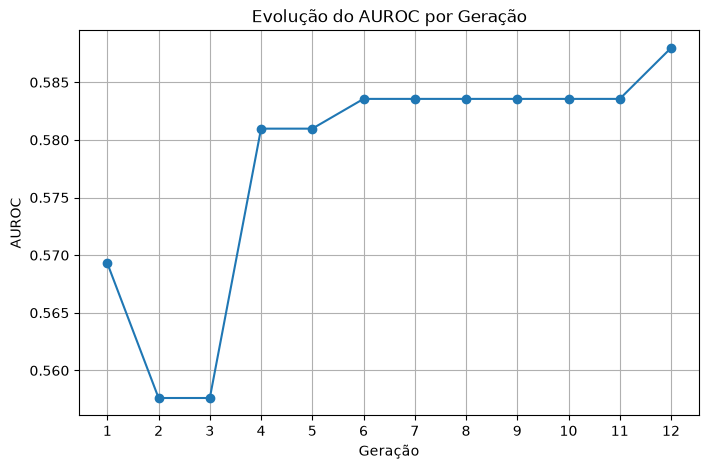

In [115]:
import matplotlib.pyplot as plt

geracoes = range(1, len(melhores_fitness) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    geracoes,
    melhores_fitness,
    marker="o"
)

plt.xlabel("Geração")
plt.ylabel("AUROC")
plt.title("Evolução do AUROC por Geração")

plt.grid(True)
plt.xticks(list(geracoes))

plt.show()

In [116]:
melhor_fitness = max(melhores_fitness)

indice_melhor = melhores_fitness.index(
    melhor_fitness
)

melhor_cromossomo = melhores_cromossomos[indice_melhor]

print("Melhor AUROC encontrado:")
print(melhor_fitness)

print("\nMelhor cromossomo:")
print(melhor_cromossomo)

Melhor AUROC encontrado:
0.5879755434782609

Melhor cromossomo:
[0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0]


In [117]:
indices_selecionados = [
    i
    for i, bit in enumerate(melhor_cromossomo)
    if bit == 1
]

features_selecionadas = X.columns[
    indices_selecionados
]

print("Features selecionadas pelo AG:")

for feature in features_selecionadas:
    print(feature)

print("\nQuantidade de features:")
print(len(features_selecionadas))

Features selecionadas pelo AG:
BTC_Variacao_Lag1
BTC_Variacao_Lag2
BTC_Variacao_Lag4
BTC_Variacao_Lag5
BTC_Distancia_WMA30
ETH_Variacao_Lag3
ETH_Variacao_Lag4
ETH_Variacao_Lag5

Quantidade de features:
8


In [118]:
X_treino_selecionado = X_treino[
    features_selecionadas
]

X_teste_selecionado = X_teste[
    features_selecionadas
]

print("Treino:")
print(X_treino_selecionado.shape)

print("\nTeste:")
print(X_teste_selecionado.shape)

Treino:
(1716, 8)

Teste:
(430, 8)


In [119]:
from sklearn.preprocessing import StandardScaler

escalador_final = StandardScaler()

X_treino_selecionado_escalado = (
    escalador_final.fit_transform(
        X_treino_selecionado
    )
)

X_teste_selecionado_escalado = (
    escalador_final.transform(
        X_teste_selecionado
    )
)

print("Padronização concluída!")

Padronização concluída!


In [120]:
from sklearn.svm import SVC

modelo_svm_final = SVC(
    kernel="rbf",
    random_state=42
)

modelo_svm_final.fit(
    X_treino_selecionado_escalado,
    y_treino
)

print("SVM final treinado com sucesso!")

SVM final treinado com sucesso!


In [121]:
previsoes_finais = modelo_svm_final.predict(
    X_teste_selecionado_escalado
)

print("Previsões realizadas com sucesso!")

print("\nQuantidade de previsões:")
print(len(previsoes_finais))

Previsões realizadas com sucesso!

Quantidade de previsões:
430


In [122]:
from sklearn.metrics import accuracy_score

acuracia_final = accuracy_score(
    y_teste,
    previsoes_finais
)

print("Accuracy final:")
print(acuracia_final)

print("\nAccuracy em porcentagem:")
print(acuracia_final * 100, "%")

Accuracy final:
0.5093023255813953

Accuracy em porcentagem:
50.93023255813953 %


In [123]:
from sklearn.metrics import roc_auc_score

pontuacoes_finais = modelo_svm_final.decision_function(
    X_teste_selecionado_escalado
)

auroc_final = roc_auc_score(
    y_teste,
    pontuacoes_finais
)

print("AUROC final:")
print(auroc_final)

AUROC final:
0.5248615198199758


Mas esse 0,62559 é fitness da validação interna, enquanto 0,52185 é o AUROC no teste final.


**AJUSTES FINAIS**

In [124]:
#ajustes finais
import random

random.seed(42)

In [125]:
# Reinicia o histórico do AG

melhores_fitness = []
melhores_cromossomos = []

# Parâmetros

tamanho_populacao = 10
numero_features = len(X.columns)
numero_geracoes = 10

# População inicial

populacao = [
    [
        random.randint(0, 1)
        for _ in range(numero_features)
    ]
    for _ in range(tamanho_populacao)
]

# Avalia a população inicial

fitness_populacao = [
    avaliar_cromossomo(cromossomo)
    for cromossomo in populacao
]

print("AG iniciado!")
print("População:", tamanho_populacao)
print("Features:", numero_features)
print("Gerações:", numero_geracoes)

AG iniciado!
População: 10
Features: 18
Gerações: 10


In [126]:
for geracao in range(numero_geracoes):

    populacao, fitness_populacao = executar_geracao(
        populacao,
        fitness_populacao
    )

    melhor_indice = fitness_populacao.index(
        max(fitness_populacao)
    )

    melhor_fitness = fitness_populacao[melhor_indice]

    print(
        f"Geração {geracao + 1:02d} | "
        f"Melhor AUROC: {melhor_fitness:.4f}"
    )

Geração 01 | Melhor AUROC: 0.5562
Geração 02 | Melhor AUROC: 0.5610
Geração 03 | Melhor AUROC: 0.5696
Geração 04 | Melhor AUROC: 0.5860
Geração 05 | Melhor AUROC: 0.5882
Geração 06 | Melhor AUROC: 0.5882
Geração 07 | Melhor AUROC: 0.5882
Geração 08 | Melhor AUROC: 0.5938
Geração 09 | Melhor AUROC: 0.6053
Geração 10 | Melhor AUROC: 0.6054


In [127]:
#pega o melhor resultado
indice_melhor_global = melhores_fitness.index(
    max(melhores_fitness)
)

melhor_auroc_ag = melhores_fitness[indice_melhor_global]

melhor_cromossomo = melhores_cromossomos[
    indice_melhor_global
]

print("\nMelhor AUROC encontrado:")
print(f"{melhor_auroc_ag:.4f}")


Melhor AUROC encontrado:
0.6053


In [128]:
#descobre as features
indices_selecionados = [
    i
    for i, bit in enumerate(melhor_cromossomo)
    if bit == 1
]

features_selecionadas = X.columns[
    indices_selecionados
]

print("\nFeatures selecionadas:")

for feature in features_selecionadas:
    print("-", feature)

print(
    "\nQuantidade de features:",
    len(features_selecionadas)
)


Features selecionadas:
- BTC_Variacao_Lag1
- BTC_Variacao_Lag3
- BTC_Variacao_Lag4
- BTC_Variacao_Lag5
- ETH_Variacao
- ETH_Variacao_Lag4
- ETH_Variacao_Lag5
- ETH_Variacao_Lag6
- ETH_Distancia_WMA30

Quantidade de features: 9


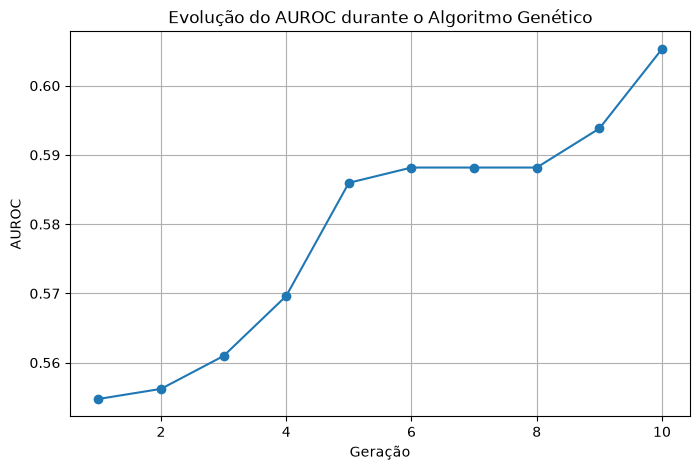

In [129]:
#plota o grafico
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(melhores_fitness) + 1),
    melhores_fitness,
    marker="o"
)

plt.xlabel("Geração")
plt.ylabel("AUROC")
plt.title("Evolução do AUROC durante o Algoritmo Genético")

plt.grid(True)

plt.show()

In [130]:
#usa as features encontradas pelo Ag
X_treino_selecionado = X_treino[
    features_selecionadas
]

X_teste_selecionado = X_teste[
    features_selecionadas
]
from sklearn.preprocessing import StandardScaler

escalador_final = StandardScaler()

X_treino_selecionado_escalado = (
    escalador_final.fit_transform(
        X_treino_selecionado
    )
)

X_teste_selecionado_escalado = (
    escalador_final.transform(
        X_teste_selecionado
    )
)


In [131]:
#treina
from sklearn.svm import SVC

modelo_svm_final = SVC(
    kernel="rbf",
    random_state=42
)

modelo_svm_final.fit(
    X_treino_selecionado_escalado,
    y_treino
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [152]:
#resultado final SVM + AG
from sklearn.metrics import accuracy_score, roc_auc_score

previsoes_finais = modelo_svm_final.predict(
    X_teste_selecionado_escalado
)

pontuacoes_finais = modelo_svm_final.decision_function(
    X_teste_selecionado_escalado
)

acuracia_final = accuracy_score(
    y_teste,
    previsoes_finais
)

auroc_final = roc_auc_score(
    y_teste,
    pontuacoes_finais
)

print("RESULTADO FINAL - SVM + AG:")

print(
    f"Accuracy: {acuracia_final:.4f}"
)

print(
    f"Accuracy (%): {acuracia_final * 100:.2f}%"
)

print(
    f"AUROC: {auroc_final:.4f}"
)

RESULTADO FINAL - SVM + AG:
Accuracy: 0.5302
Accuracy (%): 53.02%
AUROC: 0.5241


In [144]:
print("\nCOMPARAÇÃO:")

print("\nSVM sem seleção de features:")
print(f"- Accuracy: {acuracia * 100:.2f}%")
print(f"- AUROC: {auroc:.4f}")

print("\nSVM + Algoritmo Genético:")
print(f"- Accuracy: {acuracia_final * 100:.2f}%")
print(f"- AUROC: {auroc_final:.4f}")

print("\nFeatures utilizadas pelo AG:")
print(len(features_selecionadas))


COMPARAÇÃO:

SVM sem seleção de features:
- Accuracy: 50.70%
- AUROC: 0.5233

SVM + Algoritmo Genético:
- Accuracy: 53.02%
- AUROC: 0.5241

Features utilizadas pelo AG:
9


RF e KNN com seleção de atributos por AG: mesmo esquema do SVM, mas agora vamos fazer mais direto

Lembrando que ele pega as features específicas para o RF e o KNN e faz o mesmo procedimento de seleção wrapper usado no SVM é aplicado separadamente ao Random Forest e ao KNN.

Cada modelo possui seu próprio AG, portanto os cromossomos são avaliados com o próprio classificador. Isso evita reutilizar as features escolhidas pelo AG do SVM.


In [147]:
# AG GENÉRICO PARA RF E KNN (dava pra colocar o SVM, mas eu fiz o SVM primeiro pra ir aprendendo)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def executar_ag_modelo(tipo_modelo, tamanho_populacao=10, numero_geracoes=10):
    
    # executa um AG de seleção de atributos no formato wrapper, sendo que o fitness de cada cromossomo é o AUROC obtido pelo próprio classificador na validação interna.

    def criar_modelo():
        if tipo_modelo == "RF":
            return RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )

        if tipo_modelo == "KNN":
            return KNeighborsClassifier(
                n_neighbors=5,
                weights="uniform"
            )

        raise ValueError("Modelo não suportado.")

    def avaliar(cromossomo):
        indices = [
            i for i, bit in enumerate(cromossomo)
            if bit == 1
        ]

        if len(indices) == 0:
            return 0.0

        X_treino_sel = X_treino_interno.iloc[:, indices]
        X_validacao_sel = X_validacao.iloc[:, indices]

        # KNN depende da escala das variáveis; RF não.
        if tipo_modelo == "KNN":
            escalador = StandardScaler()
            X_treino_modelo = escalador.fit_transform(X_treino_sel)
            X_validacao_modelo = escalador.transform(X_validacao_sel)
        else:
            X_treino_modelo = X_treino_sel
            X_validacao_modelo = X_validacao_sel

        modelo = criar_modelo()
        modelo.fit(X_treino_modelo, y_treino_interno)

        probabilidades = modelo.predict_proba(
            X_validacao_modelo
        )[:, 1]

        return roc_auc_score(
            y_validacao,
            probabilidades
        )

    # populacao inicial
    populacao = [
        [
            random.randint(0, 1)
            for _ in range(len(X.columns))
        ]
        for _ in range(tamanho_populacao)
    ]

    fitness_populacao = [
        avaliar(cromossomo)
        for cromossomo in populacao
    ]

    melhores_fitness = []
    melhores_cromossomos = []

    def criar_nova_geracao_local(populacao, fitness_populacao):
        indice_melhor = fitness_populacao.index(
            max(fitness_populacao)
        )

        nova_populacao = [
            populacao[indice_melhor].copy()
        ]

        while len(nova_populacao) < tamanho_populacao:
            pai_1, indice_pai_1 = selecao_torneio(
                populacao, fitness_populacao
            )

            while True:
                pai_2, indice_pai_2 = selecao_torneio(
                    populacao, fitness_populacao
                )
                if indice_pai_2 != indice_pai_1:
                    break

            filho, _ = crossover(pai_1, pai_2)
            filho_mutado = mutacao(filho)
            nova_populacao.append(filho_mutado)

        return nova_populacao

    # evolucao
    for geracao in range(numero_geracoes):
        indice_melhor = fitness_populacao.index(
            max(fitness_populacao)
        )

        melhores_fitness.append(
            fitness_populacao[indice_melhor]
        )
        melhores_cromossomos.append(
            populacao[indice_melhor].copy()
        )

        populacao = criar_nova_geracao_local(
            populacao,
            fitness_populacao
        )

        fitness_populacao = [
            avaliar(cromossomo)
            for cromossomo in populacao
        ]

    # garante que o melhor indivíduo também seja considerado na população final.
    indice_melhor = fitness_populacao.index(
        max(fitness_populacao)
    )

    if fitness_populacao[indice_melhor] >= max(melhores_fitness):
        melhor_fitness = fitness_populacao[indice_melhor]
        melhor_cromossomo = populacao[indice_melhor].copy()
    else:
        indice_historico = melhores_fitness.index(
            max(melhores_fitness)
        )
        melhor_fitness = melhores_fitness[indice_historico]
        melhor_cromossomo = melhores_cromossomos[indice_historico].copy()

    indices_selecionados = [
        i for i, bit in enumerate(melhor_cromossomo)
        if bit == 1
    ]

    features = X.columns[indices_selecionados].tolist()

    return {
        "fitness": melhor_fitness,
        "cromossomo": melhor_cromossomo,
        "features": features
    }


In [151]:
# AG PRÓPRIO DO RANDOM FOREST

random.seed(42)

resultado_ag_rf = executar_ag_modelo(
    "RF",
    tamanho_populacao=10,
    numero_geracoes=10
)

features_rf_ag = resultado_ag_rf["features"]

print("RANDOM FOREST + AG:")
print(f"Melhor AUROC na validação: {resultado_ag_rf['fitness']:.4f}")
print(f"Quantidade de features: {len(features_rf_ag)}")
print("Features selecionadas:")
for feature in features_rf_ag:
    print("-", feature)


RANDOM FOREST + AG:
Melhor AUROC na validação: 0.5988
Quantidade de features: 7
Features selecionadas:
- BTC_Variacao
- BTC_Variacao_Lag3
- BTC_Variacao_Lag4
- BTC_Variacao_Lag6
- BTC_Variacao_Lag7
- ETH_Variacao_Lag6
- ETH_Distancia_WMA30


In [161]:
# treinamento e teste do RF + AG

X_treino_rf_ag = X_treino[features_rf_ag]
X_teste_rf_ag = X_teste[features_rf_ag]

modelo_rf_ag = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf_ag.fit(
    X_treino_rf_ag,
    y_treino
)

previsoes_rf_ag = modelo_rf_ag.predict(
    X_teste_rf_ag
)

probabilidades_rf_ag = modelo_rf_ag.predict_proba(
    X_teste_rf_ag
)[:, 1]

acuracia_rf_ag = accuracy_score(
    y_teste,
    previsoes_rf_ag
)

auroc_rf_ag = roc_auc_score(
    y_teste,
    probabilidades_rf_ag
)

print("RESULTADO RANDOM FOREST + AG:")
print(f"- Accuracy: {acuracia_rf_ag * 100:.2f}%")
print(f"- AUROC: {auroc_rf_ag:.4f}")


RESULTADO RANDOM FOREST + AG:
- Accuracy: 48.60%
- AUROC: 0.4566


In [162]:
# AG PRÓPRIO DO KNN
random.seed(42)

resultado_ag_knn = executar_ag_modelo(
    "KNN",
    tamanho_populacao=10,
    numero_geracoes=10
)

features_knn_ag = resultado_ag_knn["features"]

print("KNN + AG:")
print(f"Melhor AUROC na validação: {resultado_ag_knn['fitness']:.4f}")
print(f"Quantidade de features: {len(features_knn_ag)}")
print("Features selecionadas:")
for feature in features_knn_ag:
    print("-", feature)


KNN + AG:
Melhor AUROC na validação: 0.5718
Quantidade de features: 8
Features selecionadas:
- BTC_Variacao_Lag3
- BTC_Variacao_Lag5
- BTC_Variacao_Lag6
- BTC_Variacao_Lag7
- BTC_Distancia_WMA30
- ETH_Variacao
- ETH_Variacao_Lag1
- ETH_Variacao_Lag7


In [158]:
# treino e teste do KNN + AG

X_treino_knn_ag = X_treino[features_knn_ag]
X_teste_knn_ag = X_teste[features_knn_ag]

escalador_knn_ag = StandardScaler()

X_treino_knn_ag_escalado = escalador_knn_ag.fit_transform(
    X_treino_knn_ag
)

X_teste_knn_ag_escalado = escalador_knn_ag.transform(
    X_teste_knn_ag
)

modelo_knn_ag = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform"
)

modelo_knn_ag.fit(
    X_treino_knn_ag_escalado,
    y_treino
)

previsoes_knn_ag = modelo_knn_ag.predict(
    X_teste_knn_ag_escalado
)

probabilidades_knn_ag = modelo_knn_ag.predict_proba(
    X_teste_knn_ag_escalado
)[:, 1]

acuracia_knn_ag = accuracy_score(
    y_teste,
    previsoes_knn_ag
)

auroc_knn_ag = roc_auc_score(
    y_teste,
    probabilidades_knn_ag
)

print("RESULTADO KNN + AG:")
print(f"- Accuracy: {acuracia_knn_ag * 100:.2f}%")
print(f"- AUROC: {auroc_knn_ag:.4f}")


RESULTADO KNN + AG:
Accuracy: 50.93%
AUROC: 0.5085


In [163]:
print("\nSVM + Algoritmo Genético:")
print(f"- Accuracy: {acuracia_final * 100:.2f}%")
print(f"- AUROC: {auroc_final:.4f}")

print("RESULTADO RANDOM FOREST + AG:")
print(f"- Accuracy: {acuracia_rf_ag * 100:.2f}%")
print(f"- AUROC: {auroc_rf_ag:.4f}")

print("RESULTADO KNN + AG:")
print(f"- Accuracy: {acuracia_knn_ag * 100:.2f}%")
print(f"- AUROC: {auroc_knn_ag:.4f}")


SVM + Algoritmo Genético:
- Accuracy: 53.02%
- AUROC: 0.5241
RESULTADO RANDOM FOREST + AG:
- Accuracy: 48.60%
- AUROC: 0.4566
RESULTADO KNN + AG:
- Accuracy: 50.93%
- AUROC: 0.5085


### Tabela final de métricas

A tabela abaixo segue a organização usada nas tabelas de resultados do artigo: **modelo + método de seleção + configuração + Accuracy (ACC) + AUROC**. Os valores são calculados pelo próprio notebook no conjunto de teste; não são valores copiados do artigo.


In [164]:
# tabela final de métricas

resultados = pd.DataFrame({
    "Modelo": [
        "SVM",
        "Random Forest",
        "KNN"
    ],
    "Seleção de atributos": [
        "Wrapper - AG",
        "Wrapper - AG",
        "Wrapper - AG"
    ],
    "Configuração": [
        "RBF",
        "100 árvores",
        "k=5, pesos uniformes"
    ],
    "Features selecionadas": [
        len(features_selecionadas),
        len(features_rf_ag),
        len(features_knn_ag)
    ],
    "ACC": [
        acuracia_final,
        acuracia_rf_ag,
        acuracia_knn_ag
    ],
    "AUROC": [
        auroc_final,
        auroc_rf_ag,
        auroc_knn_ag
    ]
})

resultados["ACC (%)"] = resultados["ACC"] * 100

resultados = resultados[
    [
        "Modelo",
        "Seleção de atributos",
        "Configuração",
        "Features selecionadas",
        "ACC (%)",
        "AUROC"
    ]
]

resultados


,Modelo,Seleção de atributos,Configuração,Features selecionadas,ACC (%),AUROC
0,SVM,Wrapper - AG,RBF,9,53.023256,0.524061
1,Random Forest,Wrapper - AG,100 árvores,7,48.604651,0.456606
2,KNN,Wrapper - AG,"k=5, pesos uniformes",8,50.930233,0.508547


In [171]:
# previsão da direção do bitcoin no final do dia

# baixar dados recentes do Bitcoin
bitcoin_atual = yf.download(
    "BTC-USD",
    period="60d",
    auto_adjust=False
)

# baixar dados recentes do Ethereum
ethereum_atual = yf.download(
    "ETH-USD",
    period="60d",
    auto_adjust=False
)

# pega abertura e fechamento
bitcoin_atual = bitcoin_atual[["Open", "Close"]].copy()
ethereum_atual = ethereum_atual[["Open", "Close"]].copy()

bitcoin_atual.columns = ["BTC_Open", "BTC_Close"]
ethereum_atual.columns = ["ETH_Open", "ETH_Close"]

# junta BTC e ETH
dados_atuais = bitcoin_atual.join(
    ethereum_atual,
    how="inner"
)

# calcula as features sem usar o dia atual

# variações do dia anterior
dados_atuais["BTC_Variacao"] = (
    dados_atuais["BTC_Close"].pct_change().shift(1)
)

dados_atuais["ETH_Variacao"] = (
    dados_atuais["ETH_Close"].pct_change().shift(1)
)

# WMA de 30 dias, deslocada para representar
# somente informações disponíveis até o dia anterior
dados_atuais["BTC_WMA30"] = calcular_wma(
    dados_atuais["BTC_Close"],
    30
).shift(1)

dados_atuais["ETH_WMA30"] = calcular_wma(
    dados_atuais["ETH_Close"],
    30
).shift(1)

# Lags das variações
for lag in range(1, 8):

    dados_atuais[f"BTC_Variacao_Lag{lag}"] = (
        dados_atuais["BTC_Variacao"].shift(lag)
    )

    dados_atuais[f"ETH_Variacao_Lag{lag}"] = (
        dados_atuais["ETH_Variacao"].shift(lag)
    )

# Distância relativa entre o fechamento anterior e a WMA anterior
dados_atuais["BTC_Distancia_WMA30"] = (
    (dados_atuais["BTC_Close"].shift(1) - dados_atuais["BTC_WMA30"])
    / dados_atuais["BTC_WMA30"]
)

dados_atuais["ETH_Distancia_WMA30"] = (
    (dados_atuais["ETH_Close"].shift(1) - dados_atuais["ETH_WMA30"])
    / dados_atuais["ETH_WMA30"]
)

# remove linhas incompletas
dados_atuais = dados_atuais.dropna()



# preparação das features oara os 3 modelos

#SVM

X_ultimo_svm = dados_atuais[
    features_selecionadas
].iloc[[-1]]

X_ultimo_svm_escalado = escalador_final.transform(
    X_ultimo_svm
)

previsao_svm = modelo_svm_final.predict(
    X_ultimo_svm_escalado
)


#Random Forest
X_ultimo_rf = dados_atuais[
    features_rf_ag
].iloc[[-1]]

# Random Forest não precisa de escalonamento
previsao_rf = modelo_rf_ag.predict(
    X_ultimo_rf
)


#KNN

X_ultimo_knn = dados_atuais[
    features_knn_ag
].iloc[[-1]]

# KNN precisa usar o mesmo escalador utilizado no treinamento
X_ultimo_knn_escalado = escalador_knn_ag.transform(
    X_ultimo_knn
)

previsao_knn = modelo_knn_ag.predict(
    X_ultimo_knn_escalado
)


#Resulrado

print("PREDITOR BTC:")

print()
print(f"Data analisada: {dados_atuais.index[-1]}")
print(
    f"Abertura do BTC: "
    f"US$ {dados_atuais['BTC_Open'].iloc[-1]:,.2f}"
)

print()

# SVM
print("SVM:")

if previsao_svm[0] == 1:
    print("    PREVISÃO: BTC fecha ACIMA da abertura.")
else:
    print("    PREVISÃO: BTC fecha ABAIXO OU IGUAL à abertura.")

print()

# Random Forest
print("Random Forest:")

if previsao_rf[0] == 1:
    print("    PREVISÃO: BTC fecha ACIMA da abertura.")
else:
    print("    PREVISÃO: BTC fecha ABAIXO OU IGUAL à abertura.")

print()

# KNN
print("KNN:")

if previsao_knn[0] == 1:
    print("    PREVISÃO: BTC fecha ACIMA da abertura.")
else:
    print("    PREVISÃO: BTC fecha ABAIXO OU IGUAL à abertura.")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

PREDITOR BTC:

Data analisada: 2026-09-28 00:00:00
Abertura do BTC: US$ 84,457.30

SVM:
    PREVISÃO: BTC fecha ACIMA da abertura.

Random Forest:
    PREVISÃO: BTC fecha ACIMA da abertura.

KNN:
    PREVISÃO: BTC fecha ACIMA da abertura.


A saída representa uma previsão da direção do BTC para o próprio dia analisado.
As features utilizadas são calculadas somente com informações disponíveis até o dia anterior.


In [172]:
#tabela final (SVM, RF e KNN)

resultados_finais = pd.DataFrame({
    "Modelo": [
        "SVM",
        "Random Forest",
        "KNN"
    ],

    "Accuracy (%)": [
        acuracia_final * 100,
        acuracia_rf_ag * 100,
        acuracia_knn_ag * 100
    ],

    "AUROC": [
        auroc_final,
        auroc_rf_ag,
        auroc_knn_ag
    ],

    "Previsão": [
        "ACIMA da abertura" if previsao_svm[0] == 1
        else "ABAIXO OU IGUAL à abertura",

        "ACIMA da abertura" if previsao_rf[0] == 1
        else "ABAIXO OU IGUAL à abertura",

        "ACIMA da abertura" if previsao_knn[0] == 1
        else "ABAIXO OU IGUAL à abertura"
    ]
})

resultados_finais.style.format({
    "Accuracy (%)": "{:.2f}",
    "AUROC": "{:.4f}"
})

,Modelo,Accuracy (%),AUROC,Previsão
0,SVM,53.02,0.5241,ACIMA da abertura
1,Random Forest,48.60,0.4566,ACIMA da abertura
2,KNN,50.93,0.5085,ACIMA da abertura
